In [1]:
import pincell_moment_utils.postprocessing as pp
from pincell_moment_utils.datagen import DefaultPincellParameters
import numpy as np
np.random.seed(42)

def rotate180_spatial(arr):
    return np.rot90(arr, k=2, axes=(1, 2))

energy_filters = DefaultPincellParameters().get_energy_filters()
expansion = pp.random_surface_expansion(7, 5, energy_filters, incident=True, energy_bias_method='random_multiscale_gaussian')
coefficients = expansion.coefficients

Now, consider cases of rotating coefficients (by permuting surfaces), and exchanging coefficients and flipping the spatial/angular indices (corresponding to a reflection)

In [2]:
ccw_to_indexing_convention_mapping = [0, 2, 1, 3]

def ccw_to_indexing_convention(arr):
    """Takes in a 4-tuple surface permutation in ccw order and converts it to one in the indexing convention."""

    # First change the indices that the permutation refers to, from ccw order to the indexing convention.
    arr = [ ccw_to_indexing_convention_mapping[i] for i in (3, 0, 1, 2) ]

    # Now, we need to reorder the array to match the indexing convention.
    arr = [ arr[ccw_to_indexing_convention_mapping[i]] for i in range(4) ]
    return arr 

In [3]:
# 90 degree ccw rotation
coefficients_rot90 = coefficients[ccw_to_indexing_convention((3, 0, 1, 2)), :, :, :, :]
rot90 = pp.surface_expansion(coefficients_rot90, energy_filters, incident=True)

# Reflection about the horizontal = flip spatial/angular coordinates and permute surfaces
coefficients_horz_refl  = rotate180_spatial(coefficients[ccw_to_indexing_convention((0, 3, 2, 1)), :, :, :, :])
horz_refl = pp.surface_expansion(coefficients_horz_refl, energy_filters, incident=True)

Now generate source points for each of these expansions and run some pincell calculations to generate data

In [4]:
from pincell_moment_utils import config
import openmc
import h5py

def samples_to_source_file(samples, name):
    pitch = config.PITCH
    surface_perpendicular_coordinate = [pitch/2, -pitch/2, pitch/2, -pitch/2]
    surface_coord_to_3d = [ 
        lambda x: (surface_perpendicular_coordinate[0], x, 0),
        lambda x: (surface_perpendicular_coordinate[1], x, 0),
        lambda x: (x, surface_perpendicular_coordinate[2], 0),
        lambda x: (x, surface_perpendicular_coordinate[3], 0)
    ]

    source_particles = []
    for surface in range(4):
        for sample in samples[surface]:
            p = openmc.SourceParticle(r=surface_coord_to_3d[surface](sample[0]), u = (np.cos(sample[1]), np.sin(sample[1]), 0), 
                                E=sample[2])
            source_particles.append(p)

    openmc.write_source_file(source_particles, f"{name}.h5")

    # ====== Add Metadata to the Source File ======
    with h5py.File(f"{name}.h5", 'a') as f:
        f.attrs["nonzero_surfaces"] = np.array([0, 1, 2, 3], dtype=np.int32)

In [5]:
# Note equal surface weighting

num_samples = int(1E+06)
names = ['samples', 'samples_rot90', 'samples_horz_refl']
expansions = [expansion, rot90, horz_refl]
samples = []

for i, expansion in enumerate(expansions):
    samples = expansion.generate_samples(num_samples, progress=True)
    samples_to_source_file(samples, names[i])

100%|██████████| 7813/7813 [00:44<00:00, 176.88it/s]


In [6]:
import subprocess

DefaultPincellParameters(wt_enrichment=0.5, num_particles_per_generation=100000).create_script('pincell.py')

for name in names:
    proc = subprocess.Popen(
        [
            'python', 'pincell.py', 
            f'{name}.h5', 
            '--outdir', './'
        ]
    )
    proc.communicate()

/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/model/funcs.py:114: FutureWarning: The rectangular_prism(...) function has been replaced by the RectangularPrism(...) class. Future versions of OpenMC will not accept rectangular_prism.
  warn("The rectangular_prism(...) function has been replaced by the "
/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mesh.py:1092: UserWarning: Mesh has been renamed RegularMesh. Future versions of OpenMC will not accept the name Mesh.
  warnings.warn("Mesh has been renamed RegularMesh. Future versions of "
/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=1.
  warn(msg, IDWarning)
/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=2.
  warn(msg, IDWarning)
/home/mlouis9/miniconda3/envs/openmc-env/lib/python

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Simulating batch 2
 Simulating batch 3
 Simulating batch 4
 Simulating batch 5
 Simulating batch 6
 Simulating batch 7
 Simulating batch 8
 Simulating batch 9
 Simulating batch 10
 Simulating batch 11
 Simulating batch 12
 Simulating batch 13
 Simulating batch 14
 Simulating batch 15
 Simulating batch 16
 Simulating batch 17
 Simulating batch 18
 Simulating batch 19
 Simulating batch 20
 Simulating batch 21
 Simulating batch 22
 Simulating batch 23
 Simulating batch 24
 Simulating batch 25
 Simulating batch 26
 Simulating batch 27
 Simulating batch 28
 Simulating batch 29
 Simulating batch 30
 Simulating batch 31
 Simulating batch 32
 Simulating batch 33
 Simulating batch 34
 Simulating batch 35
 Simulating batch 36
 Simulating batch 37
 Simulating batch 38
 Simulating batch 39
 Simulating batch 40
 Simulating batch 41
 Simulating batch 42
 Simulating batch 43
 Simulating batch 44
 Simulating batch 45
 Simulating batch 46
 Simulating batch 47
 Simulating batch 48
 Simulating batch 49


/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/model/funcs.py:114: FutureWarning: The rectangular_prism(...) function has been replaced by the RectangularPrism(...) class. Future versions of OpenMC will not accept rectangular_prism.
  warn("The rectangular_prism(...) function has been replaced by the "
/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mesh.py:1092: UserWarning: Mesh has been renamed RegularMesh. Future versions of OpenMC will not accept the name Mesh.
  warnings.warn("Mesh has been renamed RegularMesh. Future versions of "
/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=1.
  warn(msg, IDWarning)
/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=2.
  warn(msg, IDWarning)
/home/mlouis9/miniconda3/envs/openmc-env/lib/python

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading H1 from /home/mlouis9/data/endfb-viii.0-hdf5/neutron/H1.h5
 Reading c_H_in_H2O from
 /home/mlouis9/data/endfb-viii.0-hdf5/neutron/c_H_in_H2O.h5
 Minimum neutron data temperature: 294 K
 Maximum neutron data temperature: 294 K
 Reading tallies XML file...
 Preparing distributed cell instances...
 Reading plot XML file...
 Writing summary.h5 file...
 Maximum neutron transport energy: 20000000 eV for Zr90

 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1
 Simulating batch 2
 Simulating batch 3
 Simulating batch 4
 Simulating batch 5
 Simulating batch 6
 Simulating batch 7
 Simulating batch 8
 Simulating batch 9
 Simulating batch 10
 Simulating batch 11
 Simulating batch 12
 Simulating batch 13
 Simulating batch 14
 Simulating batch 15
 Simulating batch 16
 Simulating batch 17
 Simulating batch 18
 Simulating batch 19
 Simulating batch 20
 Simulating batch 21
 Simulating batch 22
 Simulating batch 23
 Simulating batch 24
 Simulating

/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/model/funcs.py:114: FutureWarning: The rectangular_prism(...) function has been replaced by the RectangularPrism(...) class. Future versions of OpenMC will not accept rectangular_prism.
  warn("The rectangular_prism(...) function has been replaced by the "
/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mesh.py:1092: UserWarning: Mesh has been renamed RegularMesh. Future versions of OpenMC will not accept the name Mesh.
  warnings.warn("Mesh has been renamed RegularMesh. Future versions of "
/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=1.
  warn(msg, IDWarning)
/home/mlouis9/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=2.
  warn(msg, IDWarning)
/home/mlouis9/miniconda3/envs/openmc-env/lib/python

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Simulating batch 2
 Simulating batch 3
 Simulating batch 4
 Simulating batch 5
 Simulating batch 6
 Simulating batch 7
 Simulating batch 8
 Simulating batch 9
 Simulating batch 10
 Simulating batch 11
 Simulating batch 12
 Simulating batch 13
 Simulating batch 14
 Simulating batch 15
 Simulating batch 16
 Simulating batch 17
 Simulating batch 18
 Simulating batch 19
 Simulating batch 20
 Simulating batch 21
 Simulating batch 22
 Simulating batch 23
 Simulating batch 24
 Simulating batch 25
 Simulating batch 26
 Simulating batch 27
 Simulating batch 28
 Simulating batch 29
 Simulating batch 30
 Simulating batch 31
 Simulating batch 32
 Simulating batch 33
 Simulating batch 34
 Simulating batch 35
 Simulating batch 36
 Simulating batch 37
 Simulating batch 38
 Simulating batch 39
 Simulating batch 40
 Simulating batch 41
 Simulating batch 42
 Simulating batch 43
 Simulating batch 44
 Simulating batch 45
 Simulating batch 46
 Simulating batch 47
 Simulating batch 48
 Simulating batch 49


Now read outputs

In [38]:
from pincell_moment_utils.datagen import normalize_outgoing_coefs

I = 7
J = 5
G = len(energy_filters[0].values) - 1
flux_dim = (4, I, J, G, 1)
zernlike_order = 4
zernike_dim = (zernlike_order + 1) * (zernlike_order + 2) // 2

keffs = []
coefficients_out = []
wts_out = []
zernlike_out = []

for name in names:
    sp_path = f'statepoint.{name}.h5'
    mesh_tally = pp.SurfaceMeshTally(sp_path)
    coefficients = pp.compute_coefficients(mesh_tally, I, J)
    coefficients = normalize_outgoing_coefs(coefficients, energy_filters, I, J)

    # Grab the Zernike / keff / power weighting from the statepoint
    with openmc.StatePoint(sp_path) as sp:
        df = sp.get_tally(name='zernike').get_pandas_dataframe()

        # Example: gather some placeholders for demonstration
        # (your real logic to parse tallies might differ)
        tally_names = [(id, sp.tallies[id].name) for id in sp.tallies.keys()]
        nonleakage_tally_ids = [
            tid for tid, name in tally_names if 'nonleakage' in name
        ]
        nonleakage_tallies = np.array([
            sp.get_tally(id=tid).mean for tid in nonleakage_tally_ids
        ])
        keff = np.sum(np.abs(nonleakage_tallies))

        # Example: parse some weighting from tallies with IDs 6..9
        y_wts = []
        for tid in range(6, 10):
            if tid in sp.tallies:
                y_wts.append(sp.get_tally(id=tid).mean[0][0][0])
            else:
                y_wts.append(0.0)
        y_wts = np.abs(y_wts)
        if np.sum(y_wts) > 0:
            y_wts /= np.sum(y_wts)


    means = df['mean']
    std_devs = df['std. dev.']
    filtered_coeffs = [
        mean if abs(mean) >= std_dev else 0
        for mean, std_dev in zip(means, std_devs)
    ]
    filtered_coeffs = np.array(filtered_coeffs).reshape(zernike_dim, G)

    coefficients_out.append(coefficients)
    wts_out.append(y_wts)
    zernlike_out.append(filtered_coeffs)
    keffs.append(keff)


Check the keffs. Since keff is a system property, it should of course be invariant to rotations and reflections, within MC uncertainty

In [39]:
keffs

[1.2305931, 1.2297728000000003, 1.2289401999999998]

Now check the weights, they should just be the rotated/reflected counterparts of the base solution weights

In [40]:
wts_out[0]

array([0.25143778, 0.25782365, 0.2413173 , 0.24942127])

In [41]:
wts_out[1][ccw_to_indexing_convention((3, 0, 1, 2))]

array([0.25669099, 0.25354431, 0.26085127, 0.22891342])

In [42]:
wts_out[2][ccw_to_indexing_convention((0, 3, 2, 1))]

array([0.27084532, 0.24058445, 0.25466634, 0.2339039 ])

Now check the outgoing flux coefficient arrays

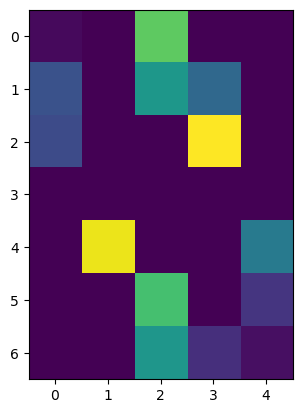

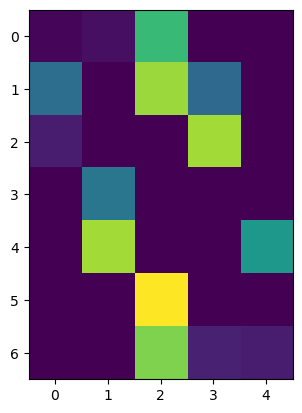

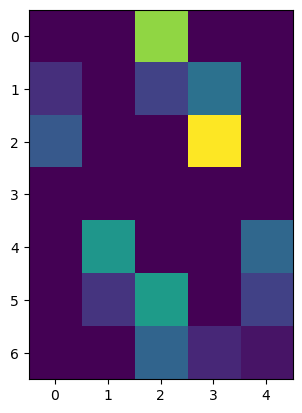

In [43]:
import matplotlib.pyplot as plt

surface_idx = 0
energy_idx = 3
plt.imshow(coefficients_out[0][surface_idx, :, :, energy_idx, 0])
plt.show()

plt.imshow(coefficients_out[1][ccw_to_indexing_convention((3, 0, 1, 2))[surface_idx], :, :, energy_idx, 0])
plt.show()

plt.imshow(rotate180_spatial(coefficients_out[2])[ccw_to_indexing_convention((0, 3, 2, 1))[surface_idx], :, :, energy_idx, 0])
plt.show()

In [44]:
surface_idx = 0
energy_idx = 3
print(coefficients_out[0][surface_idx, :, :, energy_idx, 0])

print(coefficients_out[1][ccw_to_indexing_convention((3, 0, 1, 2))[surface_idx], :, :, energy_idx, 0])

print(rotate180_spatial(coefficients_out[2])[ccw_to_indexing_convention((0, 3, 2, 1))[surface_idx], :, :, energy_idx, 0])

[[0.00991676 0.         0.29433078 0.         0.        ]
 [0.09929934 0.         0.20750143 0.13241609 0.        ]
 [0.08930838 0.         0.         0.39166232 0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.38054621 0.         0.         0.16093984]
 [0.         0.         0.27580402 0.         0.0600904 ]
 [0.         0.         0.20574427 0.05263343 0.01652924]]
[[0.0052531  0.0131936  0.21298654 0.         0.        ]
 [0.1149353  0.         0.26918364 0.10891355 0.        ]
 [0.02409876 0.         0.         0.27330907 0.        ]
 [0.         0.1241703  0.         0.         0.        ]
 [0.         0.2735383  0.         0.         0.16849827]
 [0.         0.         0.3169178  0.         0.        ]
 [0.         0.         0.25507967 0.02930918 0.02446591]]
[[0.         0.         0.35594323 0.         0.        ]
 [0.05758335 0.         0.08406873 0.15934871 0.        ]
 [0.11871207 0.         0.         0.42665045 0.        ]
 [0.        